# Super Mario Kart Snes
Basado en: https://github.com/esteveste/gym-SuperMarioKart-Snes

## 1. Preparación del Entorno


### Dependencias

A pesar de que el github nos pide instalar **gym-retro**, este no es compatible con las versiones de python que utiliza Google Colaboratory. Por ello, se usará: **stable-retro**

In [2]:
!pip install stable-retro

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.5/121.5 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 80.9 MB/s eta 0:00:00


In [3]:
!apt-get update -y
!apt-get install -y python3-opengl xvfb mesa-utils libosmesa6-dev
!pip install pyvirtualdisplay

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,385 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,643 kB]
Get:13 https://r2u.stat.illinois.edu/

###Imports necesarios

In [4]:
import stable_retro as retro
import matplotlib.pyplot as plt
from pyvirtualdisplay import Display
import time
import numpy as np

# Inicializando display para el entorno
display = Display(visible=0, size=(1400, 900))
display.start()

### Clonación y ruta


Clonaremos la carpeta de gym-SuperMarioKart-Snes en el Colab y luego enlazaremos la ruta para el entorno.

In [5]:
!git clone https://github.com/esteveste/gym-SuperMarioKart-Snes.git

Cloning into 'gym-SuperMarioKart-Snes'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (2/2), done.
remote: Total 49 (delta 1), reused 1 (delta 1), pack-reused 47 (from 1)
Receiving objects: 100% (49/49), 15.19 MiB | 11.13 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [6]:
custom_path = "/content/gym-SuperMarioKart-Snes"
retro.data.Integrations.add_custom_path(custom_path)
print("SuperMarioKart-Snes" in retro.data.list_games(inttype=retro.data.Integrations.ALL))

True


### Ajuste de Rewards

El tipo de Reward se define en scenario.json e inicialmente está en getRewardTrain que corresponde a una función de Reward definida en el script.lua.
<br><br>
Para poder tener un Reward apropiado se tiene que primero cambiar a getRewardTrainSpeed (esta es una opción de la implementación del github que aun es propensa a reward shaping)

In [7]:
import json

scenario_path = "/content/gym-SuperMarioKart-Snes/SuperMarioKart-Snes/scenario.json"

with open(scenario_path, "r") as f:
    scenario = json.load(f)

scenario["reward"]["script"] = "lua:getRewardTrainSpeed"  # o getRewardTrainSpeedLess

with open(scenario_path, "w") as f:
    json.dump(scenario, f, indent=2)

Adicionalmente, se ajustó la penalización aplicada cuando el kart se encuentra girado en sentido contrario (isTurnedAround) incrementando su magnitud de −0.1 a −2.0, con el objetivo de desalentar políticas subóptimas donde el agente se da la vuelta para seguir pasando repetidamente por el mismo checkpoint en lugar de avanzar por la pista. A su vez se aumentó el descuento cuando se choca una pared y cuando se sale de la pista. Además, se modifica la recompensa de la velocidad, haciendolo más proporcional a la velocidad.

In [8]:
import io
import re

lua_path = "/content/gym-SuperMarioKart-Snes/SuperMarioKart-Snes/script.lua"

with open(lua_path, "r") as f:
    lua_code = f.read()

new_speed_block = """function getSpeedReward()
\tlocal speed = data.kart1_speed
\tlocal reward = 0

\tif isTurnedAround() then
\t\treward = -2.0
\telseif speed > 300 then
\t\treward = math.min(speed/1000, 1)
\telse
\t\treward = -0.1
\tend

\treturn reward
end
"""

lua_code = re.sub(
    r"function getSpeedReward\(\).*?^end",
    new_speed_block.strip(),
    lua_code,
    flags=re.DOTALL | re.MULTILINE
)

lua_code = lua_code.replace(
    "if wall_hits >= 5 then",
    "if wall_hits >= 4 then"
)

lua_code = lua_code.replace(
    "if wall_steps == 500 then",
    "if wall_steps == 300 then"
)

new_experimental_block = """function getExperimentalReward()
\tlocal reward = 0

\tif data.surface == 128 then
\t\treward = -2
\telseif data.surface == 40 or data.surface == 32 then
\t\treward = -1
\telseif data.surface == 34 then
\t\treward = -1
\telse
\t\t-- superficie normal: pequeño bono por estar en pista
\t\treward = 0.1
\tend

\treturn reward
end
"""

lua_code = re.sub(
    r"function getExperimentalReward\(\).*?^end",
    new_experimental_block.strip(),
    lua_code,
    flags=re.DOTALL | re.MULTILINE
)

### Inicialización del Entorno

In [11]:
try:
    env.close()
except:
    pass

env = retro.make(
    'SuperMarioKart-Snes',
    inttype=retro.data.Integrations.ALL,
    render_mode=None
)

frames = []

obs, info = env.reset()
for i in range(500):
    obs, reward, terminated, truncated, info = env.step(
        [1,0,0,0,0,0,0,0,0,0,0,0]
    )
    frames.append(obs)
    if terminated or truncated:
        break

### Probando el Entorno

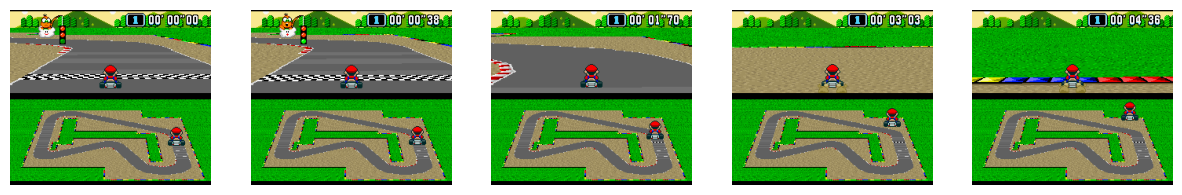

In [12]:
num_to_show = 5
step = max(1, len(frames) // num_to_show)

plt.figure(figsize=(15,3))
for j, idx in enumerate(range(0, len(frames), step)[:num_to_show]):
    plt.subplot(1, num_to_show, j+1)
    plt.imshow(frames[idx])
    plt.axis("off")
plt.show()

env.close()
display.stop()

## 2. Definición de Agentes

### Imports necesarios

In [13]:
!pip install opencv-python

In [14]:
import random
from collections import deque
from typing import Tuple
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import cv2

SEED = 123

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

Usando dispositivo: cuda


### Red Neuronal

In [15]:
class DQNNetwork(nn.Module):
    def __init__(self, obs_shape, action_size, device):
        super().__init__()
        c, h, w = obs_shape  # (C, H, W)

        self.features = nn.Sequential(
            nn.Conv2d(c, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten()
        )

        # mover features al dispositivo
        self.features.to(device)

        # tamaño después de convs
        with torch.no_grad():
            dummy = torch.zeros(1, c, h, w, device=device)
            n_flatten = self.features(dummy).shape[1]

        self.head = nn.Sequential(
            nn.Linear(n_flatten, 512),
            nn.ReLU(),
            nn.Linear(512, action_size),
        )

        # mover head también
        self.head.to(device)

    def forward(self, x):
        x = self.features(x)
        x = x.reshape(x.size(0), -1)
        return self.head(x)

### Clase Auxiliar FrameStack

In [16]:
from collections import deque

class FrameStack:
    def __init__(self, k: int = 4):
        self.k = k
        self.frames = deque(maxlen=k)

    def reset(self, first_frame: np.ndarray):
        """
        first_frame: (1, 84, 84) ya preprocesado.
        Devuelve estado (k, 84, 84) con ese frame repetido k veces.
        """
        self.frames.clear()
        for _ in range(self.k):
            self.frames.append(first_frame)
        return np.concatenate(list(self.frames), axis=0)  # (k, 84, 84)

    def step(self, frame: np.ndarray):
        """
        frame: (1, 84, 84) ya preprocesado.
        Devuelve nuevo estado (k, 84, 84).
        """
        self.frames.append(frame)
        return np.concatenate(list(self.frames), axis=0)


### Agente DQN

In [17]:
class DQNAgent:
    """DQN clásico con red target para entornos stable-retro con acciones discretas."""

    def __init__(
        self,
        obs_shape,
        action_size,
        gamma: float = 0.99,
        lr: float = 1e-4,
        epsilon_start: float = 1.0,
        epsilon_min: float = 0.1,
        epsilon_decay_replays: int = 50_000,
        memory_size: int = 5_000,
        batch_size: int = 43,
        target_update_freq: int = 100,  # C = 100 pasos para copiar pesos a la red target
    ):
        self.obs_shape = obs_shape
        self.action_size = action_size

        # dispositivo
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.model = DQNNetwork(obs_shape, action_size, device=self.device)
        self.target_model = DQNNetwork(obs_shape, action_size, device=self.device)
        self.target_model.load_state_dict(self.model.state_dict())
        self.target_model.eval()

        # hiperparámetros
        self.gamma = gamma
        self.lr = lr
        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay_replays = epsilon_decay_replays
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq

        # memoria
        self.memory = deque(maxlen=int(memory_size))

        # optimizador y pérdida (Huber / SmoothL1)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        self.criterion = nn.SmoothL1Loss()

        # contadores
        self.train_steps = 0
        self.epsilon_delta = (epsilon_start - epsilon_min) / float(epsilon_decay_replays)

    # -------------------------------------------------------
    # Utilidades
    # -------------------------------------------------------
    def _preprocess_obs(self, obs) -> np.ndarray:
      """
      Convierte la observación de stable-retro a (1, 84, 84) float32 normalizado [0,1].
      - De RGB (H, W, C) a gris.
      - Redimensiona a 84x84.
      """
      arr = np.array(obs, copy=False)

      # asegurar (H, W, C)
      if arr.ndim == 3 and arr.shape[-1] in (1, 3):
          pass  # ya está (H, W, C)
      elif arr.ndim == 2:
          # ya es gris (H, W)
          pass
      else:
          raise ValueError(f"Forma de obs inesperada: {arr.shape}")

      # RGB -> gris si tiene 3 canales
      if arr.ndim == 3 and arr.shape[-1] == 3:
          arr = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)  # (H, W)

      # resize a 84x84
      arr = cv2.resize(arr, (84, 84), interpolation=cv2.INTER_AREA)  # (84, 84)

      # normalizar y añadir canal
      arr = arr.astype(np.float32) / 255.0            # (84, 84)
      arr = np.expand_dims(arr, axis=0)               # (1, 84, 84)

      return arr

    # -------------------------------------------------------
    # API del agente
    # -------------------------------------------------------
    def remember(self, state, action, reward, next_state, done):
        """
        Almacena una transición en la memoria de replay.
        state y next_state deben ser ya (C, H, W) float32 normalizado.
        """
        self.memory.append((state, action, reward, next_state, done))

    def get_action(self, state):
        """
        Selección de acción con política epsilon-greedy.
        """
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)

        self.model.eval()
        with torch.no_grad():
            state_tensor = torch.as_tensor(
                state, dtype=torch.float32, device=self.device
            ).unsqueeze(0)  # (1, C, H, W)
            q_values = self.model(state_tensor)
            action = int(torch.argmax(q_values, dim=1).item())
        return action

    def get_action_on_test(self, state):
        """
        Versión greedy para evaluación (sin exploración).
        """
        self.model.eval()
        with torch.no_grad():
            state_tensor = torch.as_tensor(
                state, dtype=torch.float32, device=self.device
            ).unsqueeze(0)
            q_values = self.model(state_tensor)
            action = int(torch.argmax(q_values, dim=1).item())
        return action

    # -------------------------------------------------------
    # Entrenamiento
    # -------------------------------------------------------
    def replay(self):
        """
        Un paso de entrenamiento sobre un minibatch de la memoria.
        Usa red target y actualiza epsilon y target cada cierto número de pasos.
        """
        if len(self.memory) < self.batch_size:
            return

        minibatch = random.sample(self.memory, self.batch_size)

        states      = np.array([m[0] for m in minibatch], dtype=np.float32)
        actions     = np.array([m[1] for m in minibatch], dtype=np.int64)
        rewards     = np.array([m[2] for m in minibatch], dtype=np.float32)
        next_states = np.array([m[3] for m in minibatch], dtype=np.float32)
        dones       = np.array([m[4] for m in minibatch], dtype=np.float32)

        states      = torch.from_numpy(states).to(self.device)                # (B, C, H, W)
        actions     = torch.from_numpy(actions).unsqueeze(1).to(self.device)  # (B, 1)
        rewards     = torch.from_numpy(rewards).unsqueeze(1).to(self.device)  # (B, 1)
        next_states = torch.from_numpy(next_states).to(self.device)           # (B, C, H, W)
        dones       = torch.from_numpy(dones).unsqueeze(1).to(self.device)    # (B, 1)

        # Q(s,a) actual
        self.model.train()
        q_values = self.model(states).gather(1, actions)

        # max_a' Q_target(s', a')
        with torch.no_grad():
            next_q_values = self.target_model(next_states).max(1, keepdim=True)[0]
            target_q = rewards + (1.0 - dones) * self.gamma * next_q_values

        loss = self.criterion(q_values, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # contador de pasos de entrenamiento
        self.train_steps += 1

        # actualizar epsilon (decaimiento lineal)
        if self.epsilon > self.epsilon_min:
            self.epsilon -= self.epsilon_delta
            if self.epsilon < self.epsilon_min:
                self.epsilon = self.epsilon_min

        # actualización de la red target cada C pasos
        if self.train_steps % self.target_update_freq == 0:
            self.target_model.load_state_dict(self.model.state_dict())
            self.target_model.eval()

    # -------------------------------------------------------
    # Persistencia
    # -------------------------------------------------------
    def save(self, path: str):
        torch.save(self.model.state_dict(), path)

    def load(self, path: str):
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.to(self.device)
        self.model.eval()


###Agente DDQN

In [18]:
class DDQNAgent:
    """Double DQN para entornos stable-retro con acciones discretas."""

    def __init__(
        self,
        obs_shape,
        action_size,
        gamma: float = 0.99,
        lr: float = 1e-4,
        epsilon_start: float = 1.0,
        epsilon_min: float = 0.1,
        epsilon_decay_replays: int = 50_000,
        memory_size: int = 5_000,
        batch_size: int = 32,
        tau: float = 1e-3,          # soft update
    ):
        self.obs_shape = obs_shape
        self.action_size = action_size

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.model = DQNNetwork(obs_shape, action_size, device=self.device)
        self.target_model = DQNNetwork(obs_shape, action_size, device=self.device)
        self.target_model.load_state_dict(self.model.state_dict())
        self.target_model.eval()

        # hiperparámetros
        self.gamma = gamma
        self.lr = lr
        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay_replays = epsilon_decay_replays
        self.batch_size = batch_size
        self.tau = tau

        # memoria de replay
        self.memory = deque(maxlen=int(memory_size))

        # optimizador y pérdida (Huber / SmoothL1 para consistencia con DQN)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        self.criterion = nn.SmoothL1Loss()

        # contadores
        self.train_steps = 0
        self.epsilon_delta = (epsilon_start - epsilon_min) / float(epsilon_decay_replays)

    # ---------------- Utilidades ----------------
    def _preprocess_obs(self, obs) -> np.ndarray:
      """
      Convierte la observación de stable-retro a (1, 84, 84) float32 normalizado [0,1].
      - De RGB (H, W, C) a gris.
      - Redimensiona a 84x84.
      """
      arr = np.array(obs, copy=False)

      # asegurar (H, W, C)
      if arr.ndim == 3 and arr.shape[-1] in (1, 3):
          pass  # ya está (H, W, C)
      elif arr.ndim == 2:
          # ya es gris (H, W)
          pass
      else:
          raise ValueError(f"Forma de obs inesperada: {arr.shape}")

      # RGB -> gris si tiene 3 canales
      if arr.ndim == 3 and arr.shape[-1] == 3:
          arr = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)  # (H, W)

      # resize a 84x84
      arr = cv2.resize(arr, (84, 84), interpolation=cv2.INTER_AREA)  # (84, 84)

      # normalizar y añadir canal
      arr = arr.astype(np.float32) / 255.0            # (84, 84)
      arr = np.expand_dims(arr, axis=0)               # (1, 84, 84)

      return arr

    # ---------------- API ----------------
    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def get_action(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)

        self.model.eval()
        with torch.no_grad():
            state_tensor = torch.as_tensor(
                state, dtype=torch.float32, device=self.device
            ).unsqueeze(0)  # (1, C, H, W)
            q_values = self.model(state_tensor)
            action = int(torch.argmax(q_values, dim=1).item())
        return action

    def get_action_on_test(self, state):
        self.model.eval()
        with torch.no_grad():
            state_tensor = torch.as_tensor(
                state, dtype=torch.float32, device=self.device
            ).unsqueeze(0)
            q_values = self.model(state_tensor)
            action = int(torch.argmax(q_values, dim=1).item())
        return action

    # ---------------- Entrenamiento ----------------
    def replay(self):
        if len(self.memory) < self.batch_size:
            return

        minibatch = random.sample(self.memory, self.batch_size)

        states      = np.array([m[0] for m in minibatch], dtype=np.float32)
        actions     = np.array([m[1] for m in minibatch], dtype=np.int64)
        rewards     = np.array([m[2] for m in minibatch], dtype=np.float32)
        next_states = np.array([m[3] for m in minibatch], dtype=np.float32)
        dones       = np.array([m[4] for m in minibatch], dtype=np.float32)

        states      = torch.from_numpy(states).to(self.device)
        actions     = torch.from_numpy(actions).unsqueeze(1).to(self.device)
        rewards     = torch.from_numpy(rewards).unsqueeze(1).to(self.device)
        next_states = torch.from_numpy(next_states).to(self.device)
        dones       = torch.from_numpy(dones).unsqueeze(1).to(self.device)

        # Q(s,a) actual (red online)
        self.model.train()
        q_values = self.model(states).gather(1, actions)

        # Double DQN:
        # 1) acciones argmax con la red online en s'
        with torch.no_grad():
            online_next_q = self.model(next_states)                 # Q_online(s', ·)
            next_actions = online_next_q.argmax(1, keepdim=True)   # a* = argmax_a Q_online(s', a)

            # 2) valor de esas acciones usando la red target
            target_next_q = self.target_model(next_states).gather(1, next_actions)
            target_q = rewards + (1.0 - dones) * self.gamma * target_next_q

        loss = self.criterion(q_values, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # actualizar epsilon
        self.train_steps += 1
        if self.epsilon > self.epsilon_min:
            self.epsilon -= self.epsilon_delta
            if self.epsilon < self.epsilon_min:
                self.epsilon = self.epsilon_min

        # soft update de la red target
        self.soft_update()

    def soft_update(self):
        """
        Actualización suave de la red target:
        θ_target ← (1 − τ) θ_target + τ θ_online
        """
        with torch.no_grad():
            for target_param, param in zip(self.target_model.parameters(),
                                           self.model.parameters()):
                target_param.data.copy_(
                    (1.0 - self.tau) * target_param.data + self.tau * param.data
                )

    # ---------------- Guardar / cargar ----------------
    def save(self, path: str):
        torch.save(self.model.state_dict(), path)

    def load(self, path: str):
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.to(self.device)
        self.model.eval()


### Función para Visualizar Pipeline

In [19]:
def visualizar_pipeline_secuencia(env, agent, action_list, num_steps=4, action_idx_avanzar=1):
    """
    Muestra cómo se transforma una secuencia de frames mientras el kart avanza.
    - action_idx_avanzar: índice en ACTION_LIST que corresponde a 'acelerar' (B).
    """
    obs, info = env.reset()

    frame_original = obs

    # inicializar FrameStack
    fs = FrameStack(k=4)

    # primer frame preprocesado
    frame_gray = agent._preprocess_obs(obs)      # (1, 84, 84)
    state = fs.reset(frame_gray)                 # (4, 84, 84)

    # aplicar la misma acción (acelerar) durante num_steps-1 pasos para generar movimiento
    for _ in range(num_steps - 1):
        buttons = action_list[action_idx_avanzar]   # p.ej. índice 1 = B: acelerar
        next_obs, reward, done, truncated, info = env.step(buttons)
        next_frame = agent._preprocess_obs(next_obs)
        state = fs.step(next_frame)                 # actualiza stack

        if done or truncated:
            break

    # ahora mostramos: original, gris actual y las 4 capas del stack
    fig, axes = plt.subplots(1, 6, figsize=(18, 4))

    # 1) original RGB
    axes[0].imshow(frame_original)
    axes[0].set_title("Frame original\nRGB")
    axes[0].axis("off")

    # 2) último frame gris 84x84
    axes[1].imshow(state[-1], cmap="gray")
    axes[1].set_title("Gris 84x84\núltimo frame")
    axes[1].axis("off")

    # 3–6) las 4 capas del stack (historia de movimiento)
    for i in range(4):
        axes[2 + i].imshow(state[i], cmap="gray")
        axes[2 + i].set_title(f"Stack {i+1}")
        axes[2 + i].axis("off")

    plt.tight_layout()
    plt.show()

    return frame_original, state


## 3. Uso de Agentes

### Función Genérica de Entrenamiento

In [20]:
def rolling_mean_std(x, window: int = 20):
    """Devuelve (mean, std) para cada índice usando ventana 'window' hacia atrás (incluye el índice actual)."""
    x = np.asarray(x, dtype=np.float32)
    means = np.empty_like(x)
    stds = np.empty_like(x)
    for i in range(len(x)):
        start = max(0, i - window + 1)
        w = x[start:i+1]
        means[i] = w.mean() if len(w) else np.nan
        stds[i] = w.std(ddof=0) if len(w) else np.nan
    return means, stds

In [22]:
def train_agent(
    AgentClass,
    action_list,
    num_episodes=10,
    max_steps_per_episode=500,
    update_every=4,
    env_kwargs=None,
    agent_kwargs=None,
    seed=SEED, # Asegúrate de que SEED esté definido en tu entorno
    skip_frames=4
):
    if env_kwargs is None:
        env_kwargs = {}
    if agent_kwargs is None:
        agent_kwargs = {}

    # cerrar entorno anterior si existe
    try:
        env.close()
    except:
        pass

    env = retro.make(
        game="SuperMarioKart-Snes",
        inttype=retro.data.Integrations.ALL,
        render_mode=None,
        **env_kwargs,
    )

    frame_stack = FrameStack(k=4)

    obs, info = env.reset(seed=seed)
    for _ in range(60):  # ~60 steps de countdown
      obs, _, _, _, info = env.step(ACTION_LIST[1])

    # agente temporal para obtener shape
    tmp_agent = AgentClass(
        obs_shape=(4, 84, 84),
        action_size=len(action_list),
        **agent_kwargs,
    )
    first_frame = tmp_agent._preprocess_obs(obs)      # (1, 84, 84)
    state = frame_stack.reset(first_frame)            # (4, 84, 84)

    agent = AgentClass(
        obs_shape=state.shape,
        action_size=len(action_list),
        **agent_kwargs,
    )

    # -------- NUEVO: tracking de mejor episodio de train --------
    best_train_return = -1e9
    best_train_frames = None

    # -------- NUEVO: variables para estadísticas y plots --------
    episode_scores = []
    epsilons = []
    t0 = time.perf_counter()

    for ep in range(num_episodes):
        print(f"\n=== Episodio {ep+1}/{num_episodes} ({AgentClass.__name__}) ===")
        obs, info = env.reset()

        first_frame = agent._preprocess_obs(obs)
        state = frame_stack.reset(first_frame)

        done = False
        truncated = False
        total_reward = 0.0
        step = 0

        episode_frames = []

        while step < max_steps_per_episode and not (done or truncated):
            action_idx = agent.get_action(state)
            buttons = action_list[action_idx]

            # guardar frame original de entrenamiento (opcional para video)
            episode_frames.append(obs)

            #next_obs, reward, done, truncated, info = env.step(buttons)

            accumulated_reward = 0.0
            for _ in range(skip_frames):
                episode_frames.append(obs) # Guardamos obs para el video

                next_obs, reward, done, truncated, info = env.step(buttons)
                accumulated_reward += reward
                obs = next_obs

                if done or truncated:
                    break

            next_frame = agent._preprocess_obs(next_obs)
            next_state = frame_stack.step(next_frame)
            reward = accumulated_reward

            agent.remember(state, action_idx, reward, next_state, done or truncated)

            if len(agent.memory) >= agent.batch_size and step % update_every == 0:
                agent.replay()
                print(
                    f"  [ep {ep+1}] step {step}: replay() OK, reward={reward:.2f}, eps={agent.epsilon:.3f}"
                )

            state = next_state
            obs = next_obs
            total_reward += reward
            step += 1

            #if total_reward < -500:
              #break

        # -------- NUEVO: Guardar datos del episodio para los plots --------
        episode_scores.append(total_reward)
        epsilons.append(float(agent.epsilon))

        print(f"Ep {ep+1} | R = {total_reward:.1f} | eps = {agent.epsilon:.3f}")

        # -------- ACTUALIZAR mejor episodio de entrenamiento --------
        if total_reward > best_train_return:
            best_train_return = total_reward
            best_train_frames = episode_frames
            print(f"  >>> Nuevo mejor episodio de TRAIN: R = {best_train_return:.1f}")
            agent.save("dqn_best_train.pth")

    env.close()

    # ==========================================
    # SECCIÓN DE ESTADÍSTICAS Y PLOTS INTEGRADA
    # ==========================================
    total_time = time.perf_counter() - t0

    scores_np = np.asarray(episode_scores, dtype=np.float32)
    eps_np = np.asarray(epsilons, dtype=np.float32)

    # Estadísticas globales
    max_score = float(scores_np.max())
    first_max_ep = int(np.argmax(scores_np)) + 1  # 1-based
    mean_all = float(scores_np.mean())
    std_all = float(scores_np.std(ddof=0))

    # Últimos 20 (o los que haya si son menos de 20)
    last_k = min(20, len(scores_np))
    mean_last = float(scores_np[-last_k:].mean())
    std_last = float(scores_np[-last_k:].std(ddof=0))

    print("\n===== Estadísticas =====")
    print(f"Tiempo total entrenamiento: {total_time:.2f} s")
    print(f"Máximo score (Return): {max_score:.2f} (primera vez en episodio {first_max_ep})")
    print(f"Promedio (todo): {mean_all:.2f} ± {std_all:.2f}")
    print(f"Promedio (últimos {last_k}): {mean_last:.2f} ± {std_last:.2f}")

    # Plots: score + media móvil con bandas
    # Asume que tienes definida globalmente la función rolling_mean_std.
    # Si la ventana es mayor a la cantidad de episodios, puede dar error en numpy,
    # así que la ajustamos dinámicamente con `min(20, len(scores_np))`
    window_size = min(20, len(scores_np))
    mov_mean, mov_std = rolling_mean_std(scores_np, window=window_size)

    x = np.arange(1, len(scores_np) + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(x, scores_np, linewidth=1, label="Score (Return) por episodio")
    plt.plot(x, mov_mean, linewidth=2, label=f"Media móvil ({window_size})")
    plt.fill_between(x, mov_mean - mov_std, mov_mean + mov_std, alpha=0.2, label=f"±1 std (ventana {window_size})")
    plt.xlabel("Episodio")
    plt.ylabel("Score (Return)")
    plt.title(f"Entrenamiento: {AgentClass.__name__} en SuperMarioKart-Snes")
    plt.legend()
    plt.show()

    # Plot epsilon
    plt.figure(figsize=(10, 3.5))
    plt.plot(x, eps_np, linewidth=2)
    plt.xlabel("Episodio")
    plt.ylabel("Epsilon")
    plt.title("Epsilon por episodio")
    plt.show()

    history = {
        "scores": episode_scores,
        "epsilons": epsilons,
        "total_time_s": total_time,
        "max_score": max_score,
        "first_max_episode": first_max_ep,
        "mean_all": mean_all,
        "std_all": std_all,
        "mean_last20": mean_last,
        "std_last20": std_last,
    }

    return history, agent, best_train_frames, best_train_return

### Función para Recopilar Frames

In [23]:
def run_episode_and_record(agent, action_list, max_steps=2000,seed=None):
    """
    Ejecuta un episodio de test con política greedy y guarda los frames RGB.
    Crea y cierra su propio entorno.
    """
    env = retro.make(
        game="SuperMarioKart-Snes",
        inttype=retro.data.Integrations.ALL,
        render_mode=None,
    )

    if seed is not None:
        obs, info = env.reset(seed=seed)
    else:
        obs, info = env.reset()

    frames = []
    total_reward = 0.0
    done = False
    truncated = False
    step = 0

    # FrameStack para construir el estado (4, 84, 84)
    fs = FrameStack(k=4)
    frame = agent._preprocess_obs(obs)
    state = fs.reset(frame)

    while step < max_steps and not (done or truncated):
        # política greedy (sin exploración)
        action_idx = agent.get_action_on_test(state)
        buttons = action_list[action_idx]

        # guardar frame original
        frames.append(obs)

        next_obs, reward, done, truncated, info = env.step(buttons)
        next_frame = agent._preprocess_obs(next_obs)
        state = fs.step(next_frame)

        obs = next_obs
        total_reward += reward
        step += 1

    env.close()
    print(f"Episodio de test | R = {total_reward:.1f}, steps = {step}")
    return frames, total_reward

### Función para Evaluar Agentes

In [24]:
def evaluate_agent_once(
    agent,
    action_list,
    max_steps=15000,
    seed=SEED,   # fija uno
):
    frames, total_reward = run_episode_and_record(
        agent=agent,
        action_list=action_list,
        max_steps=max_steps,
        seed=seed,
    )
    print(f"Retorno de test (seed={seed}): {total_reward:.1f}")
    return frames, total_reward


### Definiciones Iniciales

In [25]:
# Orden de botones stable-retro SNES: [B, Y, Select, Start, Up, Down, Left, Right, A, X, L, R]
ACTION_LIST = [
    # 0: Nada
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    # 1–2: Acciones básicas
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # B: acelerar
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Y: frenar
    # 3–6: Girar sin acelerar
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # Left
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],  # Right
    [0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # Y+Left (frenar+izquierda)
    [0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],  # Y+Right (frenar+derecha)
    # 7–8: Acelerar y girar
    [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # B+Left
    [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],  # B+Right
    # 9–11: Salto / powerslide
    #[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],  # B+L (salto/powerslide)
    [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0],  # B+Left+L
    [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1],  # B+Right+R
]

common_agent_kwargs = dict(
    gamma=0.99,
    lr=1e-4,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay_replays=20_000,
    memory_size=8_000,
)

num_episodes = 300
max_steps_per_episode = 3000
update_every = 4

### Visualización de Pipeline

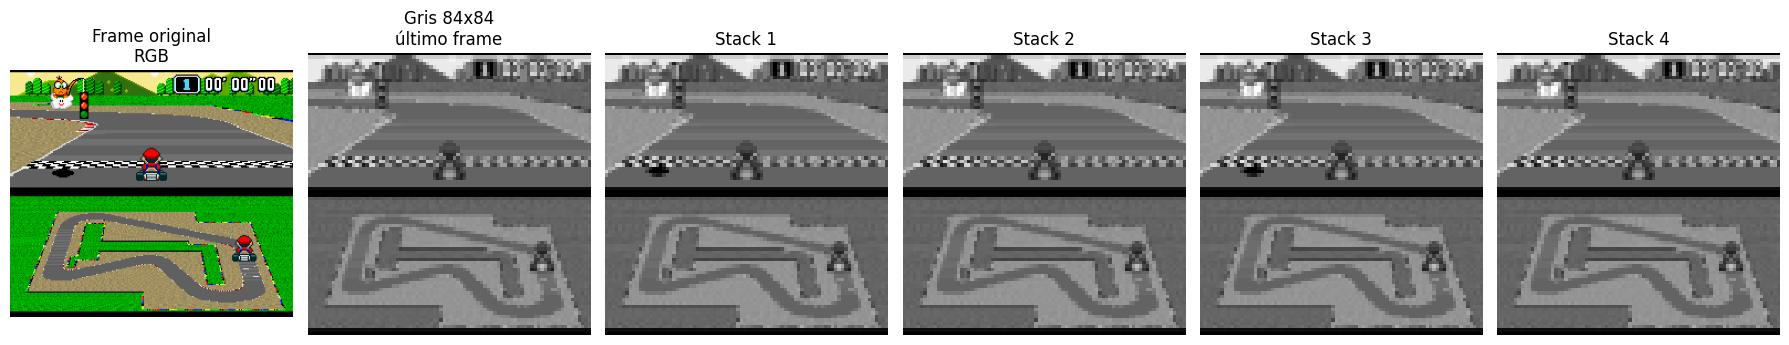

In [ ]:
try:
  env.close()
except:
  pass

env = retro.make(
    game="SuperMarioKart-Snes",
    inttype=retro.data.Integrations.ALL,
    render_mode=None,
)

demo_agent = DQNAgent(
    obs_shape=(4, 84, 84),
    action_size=len(ACTION_LIST),
    **common_agent_kwargs,
)

# action_idx_avanzar=1 asumiendo que ACTION_LIST[1] es "B: acelerar"
frame_original, state = visualizar_pipeline_secuencia(
    env, demo_agent, ACTION_LIST, num_steps=8, action_idx_avanzar=1
)

env.close()

### Agente DQN

In [26]:
env.close()

In [27]:
import sys

class Logger:
    def __init__(self, filename):
        self.terminal = sys.stdout
        self.log = open(filename, "w")
    def write(self, message):
        self.terminal.write(message)
        self.log.write(message)
    def flush(self):
        self.terminal.flush()
        self.log.flush()

sys.stdout = Logger("training_log.txt")

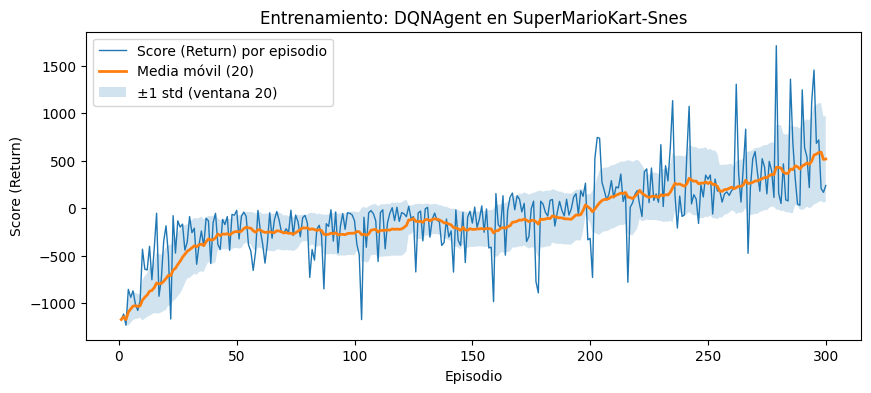

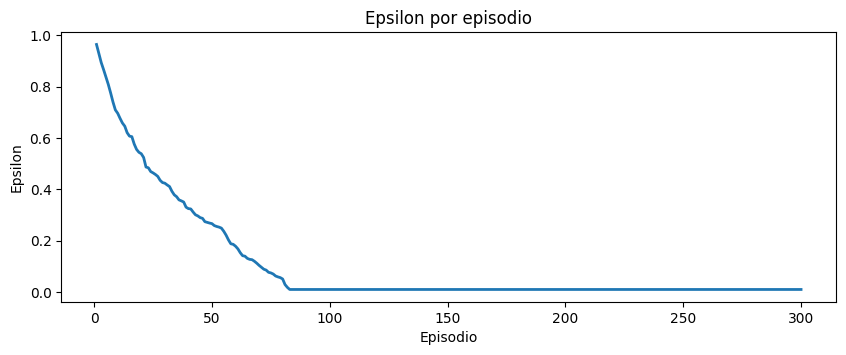

In [28]:
history_dqn, dqn_agent, train_best_frames, train_best_R = train_agent(
    AgentClass=DQNAgent,
    action_list=ACTION_LIST,
    num_episodes=num_episodes,
    max_steps_per_episode=max_steps_per_episode,
    update_every=update_every,
    agent_kwargs={**common_agent_kwargs, "batch_size": 64, "target_update_freq": 200},
)

print("Mejor retorno durante TRAIN:", train_best_R)

In [29]:
import imageio

imageio.mimsave("dqn_mariokart_train_best.mp4", train_best_frames, fps=30)

In [30]:
from google.colab import files
sys.stdout = sys.stdout.terminal  # restaurar stdout normal
files.download("training_log.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Agente DDQN

In [ ]:
sys.stdout = Logger("training_log_ddqn.txt")

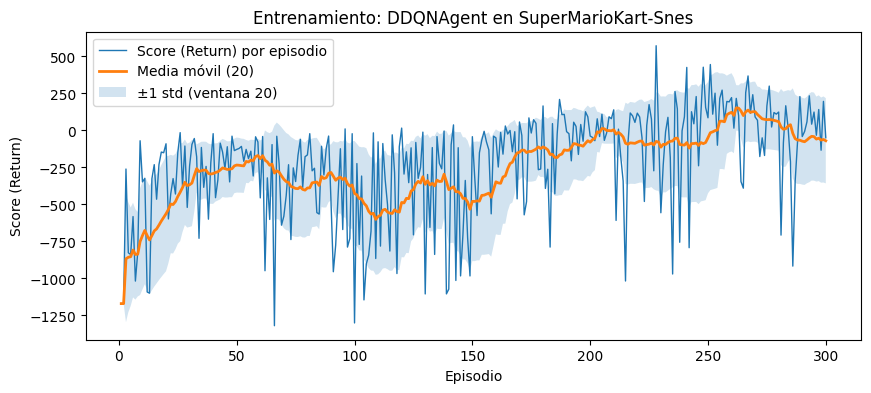

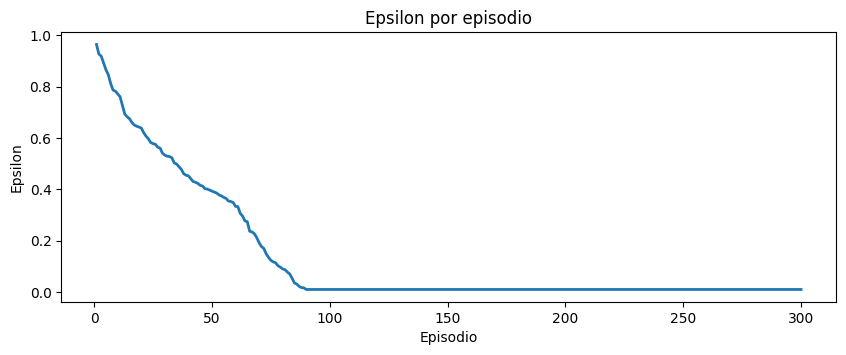

In [ ]:
env.close()
ddqn_history, ddqn_agent, ddqn_train_best_frames, ddqn_train_best_R = train_agent(
    AgentClass=DDQNAgent,
    action_list=ACTION_LIST,
    num_episodes=num_episodes,
    max_steps_per_episode=max_steps_per_episode,
    update_every=update_every,
    agent_kwargs={**common_agent_kwargs, "batch_size": 64, "tau": 1e-3},
)

In [ ]:
import imageio
imageio.mimsave("ddqn_mariokart_train_best.mp4", ddqn_train_best_frames, fps=30)

In [ ]:
sys.stdout = sys.stdout.terminal  # restaurar stdout normal
files.download("training_log_ddqn.txt")